<a href="https://colab.research.google.com/github/vugaer/ml-models/blob/main/ML-Course-Tulsa/L1-HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initialization


In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression

### Experimental

from lightgbm import LGBMClassifier

# Classification - Digits

In [38]:
digits = load_digits()
X = digits.data
y = digits.target

In [39]:
def predict_digit(X, y, model, start=0, stop=10, res_w=8, res_h=8, figsize=(15, 3)):
  """ we can use this to visualise our model! """
  test_images = X[start:stop].reshape(-1, res_w, res_h)
  model.fit(X, y)
  guesses = model.predict(X[start:stop])
  pred_img = np.hstack(test_images)
  plt.figure(figsize=figsize)
  plt.imshow(pred_img, cmap='gray')
  plt.title(f'Predicted: {guesses}')
  plt.axis('off')  # to disable X and Y axis on the plot
  plt.show()
  return guesses

## KNN

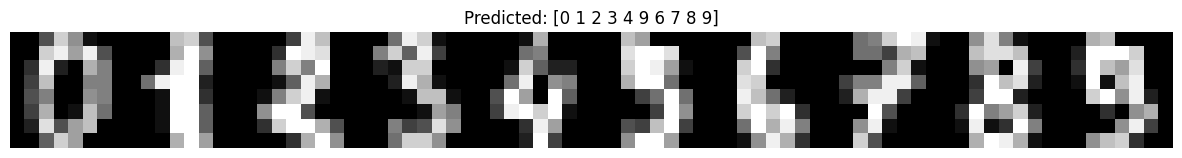

array([0, 1, 2, 3, 4, 9, 6, 7, 8, 9])

In [40]:
# Using KNN
predict_digit(X, y, KNeighborsClassifier(n_neighbors=3), 0, 10)

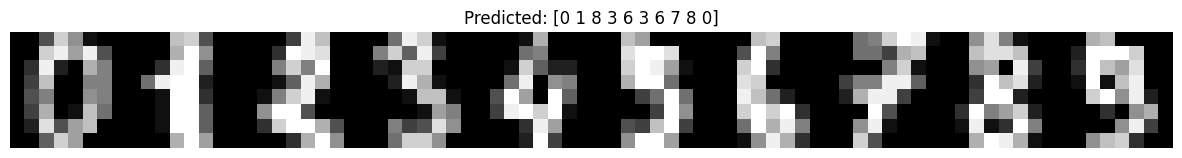

array([0, 1, 8, 3, 6, 3, 6, 7, 8, 0])

In [41]:
# Using KNN (neighbors 1000)
# It messes up
predict_digit(X, y, KNeighborsClassifier(n_neighbors=1000), 0, 10)

## Decision Tree

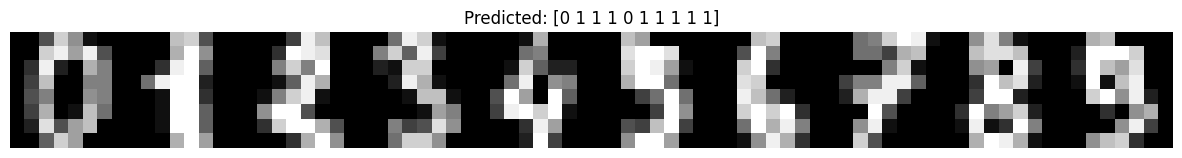

array([0, 1, 1, 1, 0, 1, 1, 1, 1, 1])

In [42]:
# Using DecisionTreeClassifier
predict_digit(X, y, DecisionTreeClassifier(max_depth=1), 0, 10)

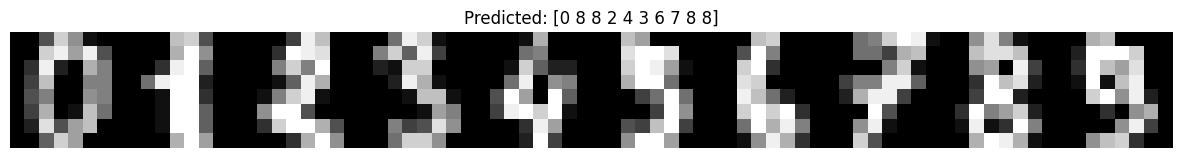

array([0, 8, 8, 2, 4, 3, 6, 7, 8, 8])

In [43]:
# Using DecisionTreeClassifier
predict_digit(X, y, DecisionTreeClassifier(max_depth=5), 0, 10)

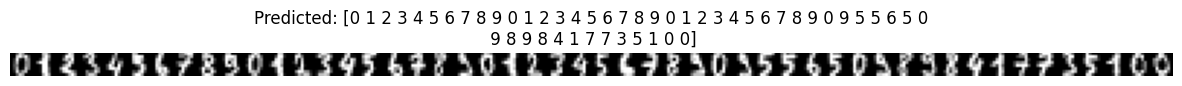

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1,
       2, 3, 4, 5, 6, 7, 8, 9, 0, 9, 5, 5, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7,
       7, 3, 5, 1, 0, 0])

In [44]:
# Using DecisionTreeClassifier
predict_digit(X, y, DecisionTreeClassifier(max_depth=10), 0, 50)
# all correct btw

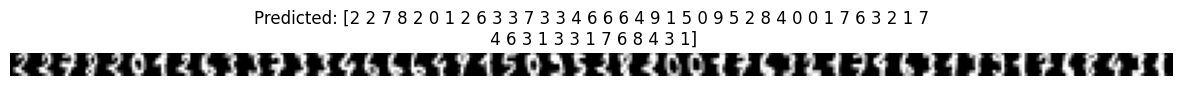

array([2, 2, 7, 8, 2, 0, 1, 2, 6, 3, 3, 7, 3, 3, 4, 6, 6, 6, 4, 9, 1, 5,
       0, 9, 5, 2, 8, 4, 0, 0, 1, 7, 6, 3, 2, 1, 7, 4, 6, 3, 1, 3, 3, 1,
       7, 6, 8, 4, 3, 1])

In [45]:
# Using DecisionTreeClassifier
predict_digit(X, y, DecisionTreeClassifier(max_depth=10), 50, 100)
# all correct btw

# Classification - Moons

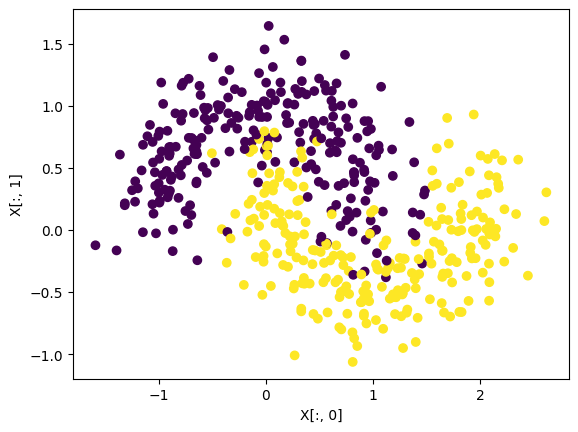

In [46]:
moons = make_moons(n_samples=500, noise=0.25)
X, y = moons
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel('X[:, 0]')
plt.ylabel('X[:, 1]')
plt.show()

In [47]:
def pltmoons(X_test, y_test, y_pred, model='NaN'):
  fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(15, 5))

  ax1.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)
  ax1.set_title('Predicted')
  ax1.set_xlabel(f'Accuracy: {np.mean(y_pred == y_test)}')
  ax2.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
  ax2.set_xlabel('Geninue one')
  ax2.set_title('Real')

  fig.suptitle(f'{model} versus Real Dataset')
  fig.show()

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = np.asarray(X_train)
X_test  = np.asarray(X_test)

## KNN

In [49]:
# GPT Assisted*

params = {
    "n_neighbors": 10,
    "weights": "uniform",  # "uniform" or "distance" or callable
    "algorithm": "auto",  # "auto", "ball_tree", "kd_tree", "brute"
    "leaf_size": 30,
    "p": 2,
    "metric": "minkowski",
    "metric_params": None,
    "n_jobs": None
}

knn = KNeighborsClassifier(**params)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

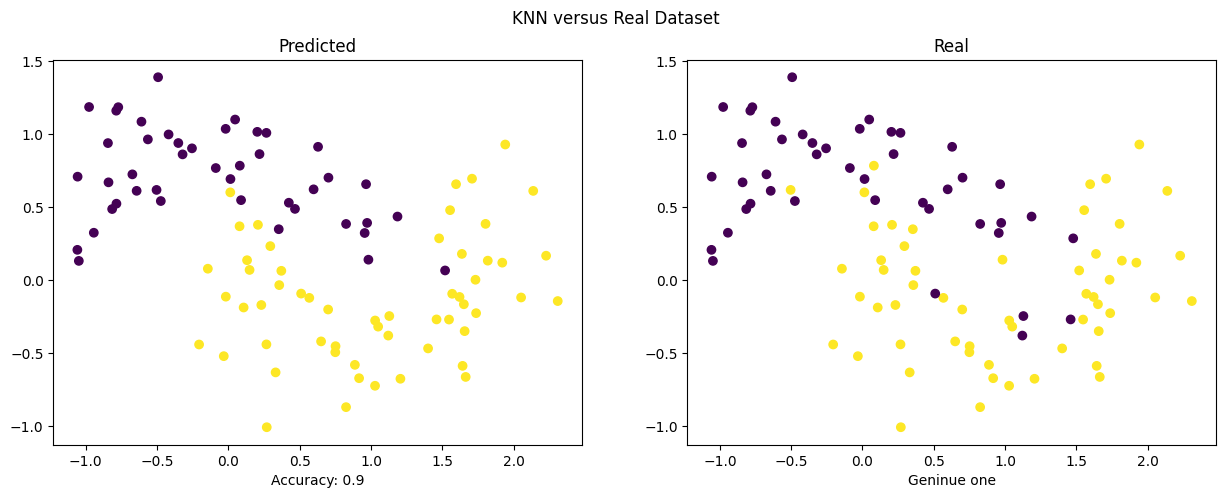

In [50]:
pltmoons(X_test, y_test, y_pred, 'KNN')

## Decision Tree

In [51]:
params = {
    "criterion": "gini",              # "gini", "entropy", "log_loss"
    "splitter": "best",               # "best", "random"
    "max_depth": 20,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "min_weight_fraction_leaf": 0.0,
    "max_features": None,             # int, float, "sqrt", "log2", or None
    "random_state": None,
    "max_leaf_nodes": None,
    "min_impurity_decrease": 0.0,
    "class_weight": None,             # dict, "balanced", or None
    "ccp_alpha": 0.0
}

dt = DecisionTreeClassifier(**params)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)


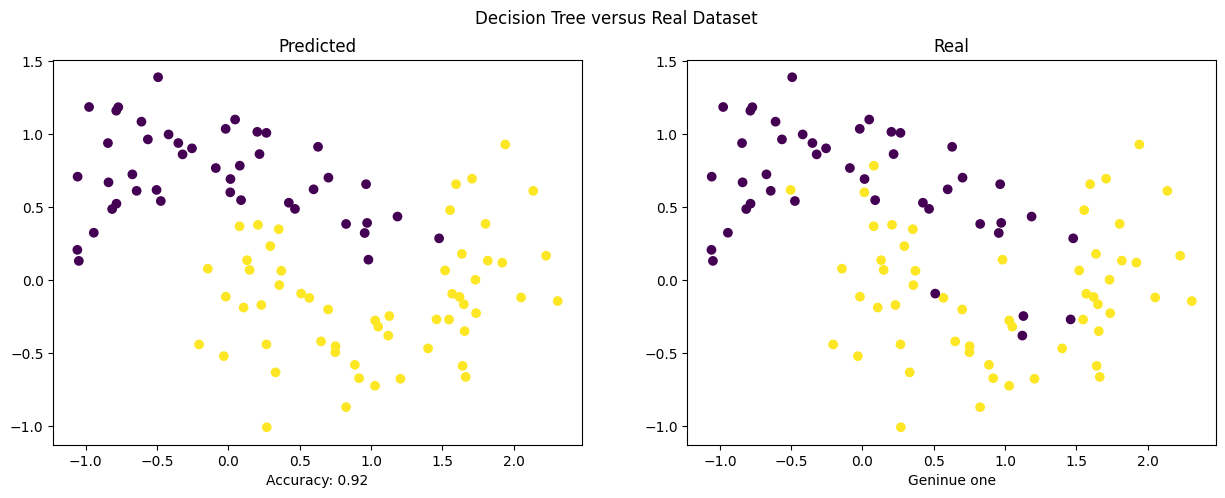

In [52]:
pltmoons(X_test, y_test, y_pred, model='Decision Tree')

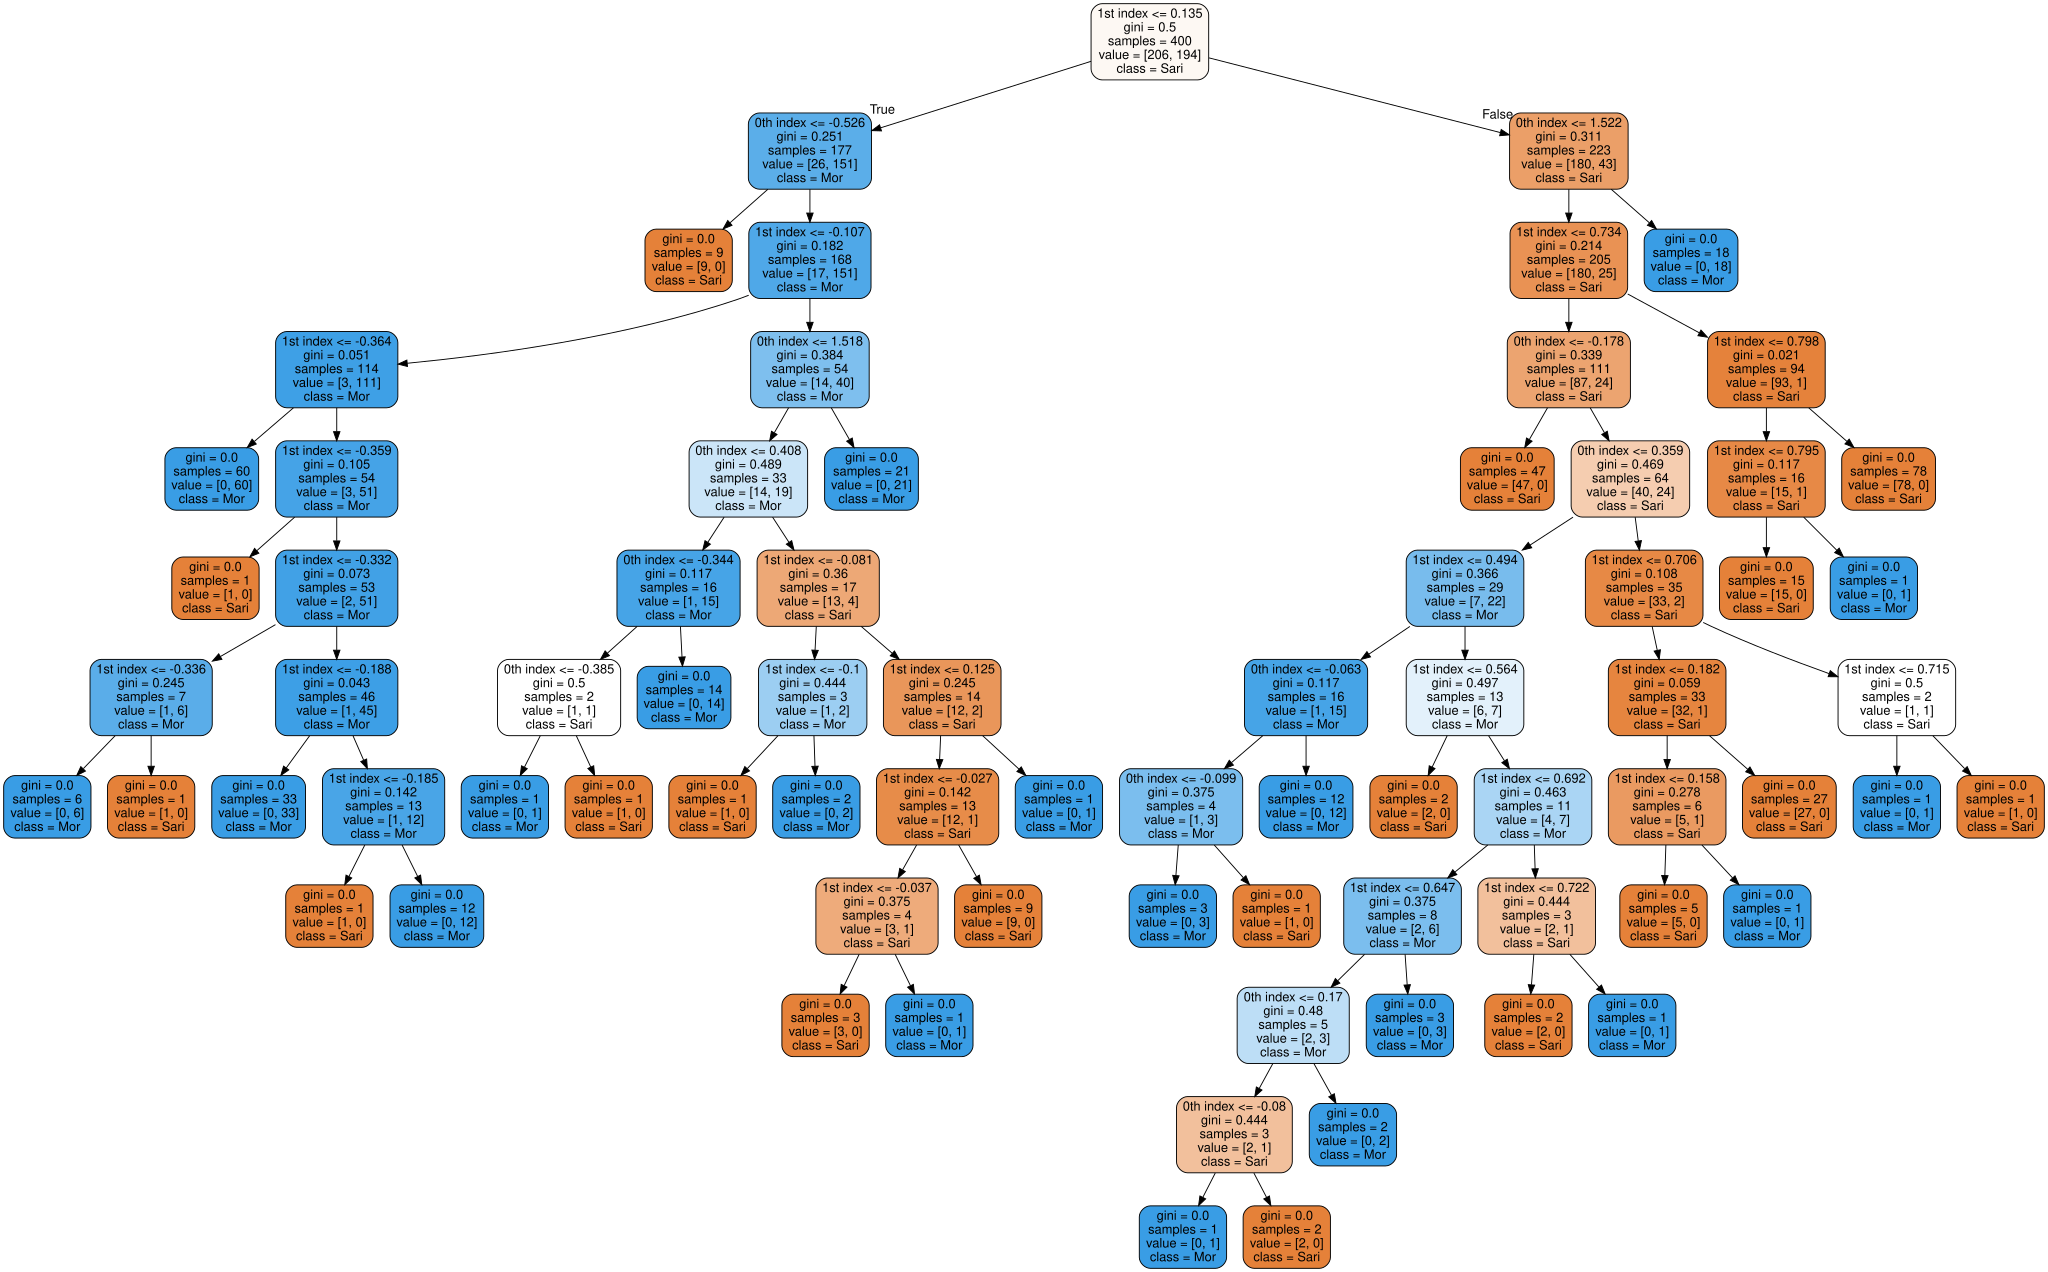

In [65]:
from sklearn.tree import export_graphviz

export_graphviz(
        dt,
        out_file=str("moons_trees.png"),
        feature_names=["0th index", "1st index"],
        class_names=['Sari', 'Mor'],
        rounded=True,
        filled=True
    )

from graphviz import Source

Source.from_file("moons_trees.png")

## Support Vector Classifier (SVC)

In [54]:
params = {
    "C": 4.0,                          # regularization strength
    "kernel": "rbf",                   # "linear", "poly", "rbf", "sigmoid", "precomputed"
    "degree": 3,                       # only for "poly"
    "gamma": "scale",                  # "scale", "auto", or float
    "coef0": 0.0,                      # for "poly" and "sigmoid"
    "shrinking": True,
    "probability": False,              # True enables predict_proba (slower)
    "tol": 1e-3,
    "cache_size": 200,                 # MB
    "class_weight": None,              # dict, "balanced", or None
    "verbose": False,
    "max_iter": -1,                    # -1 = no limit
    "decision_function_shape": "ovr",  # "ovr" or "ovo"
    "break_ties": False,
    "random_state": None               # only used when probability=True
}

svc = SVC(**params)
svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)

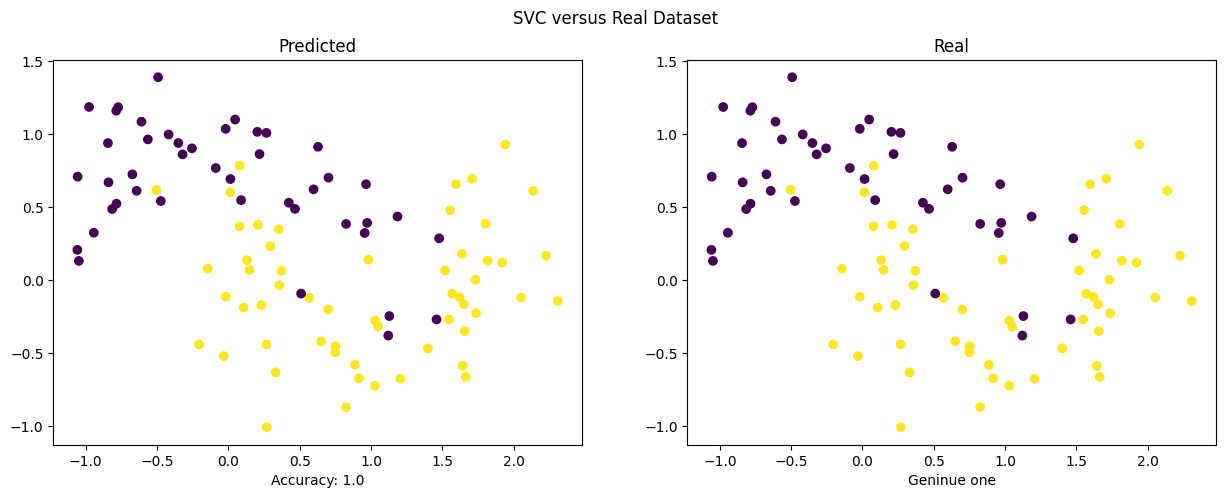

In [55]:
pltmoons(X_test, y_test, y_test, model='SVC')  # 100% Result

In [56]:
params = {
    "n_estimators": 100,
    "learning_rate": 1.0,
    "random_state": None
}

ada = AdaBoostClassifier(**params)
ada.fit(X_train, y_train)

y_pred = ada.predict(X_test)

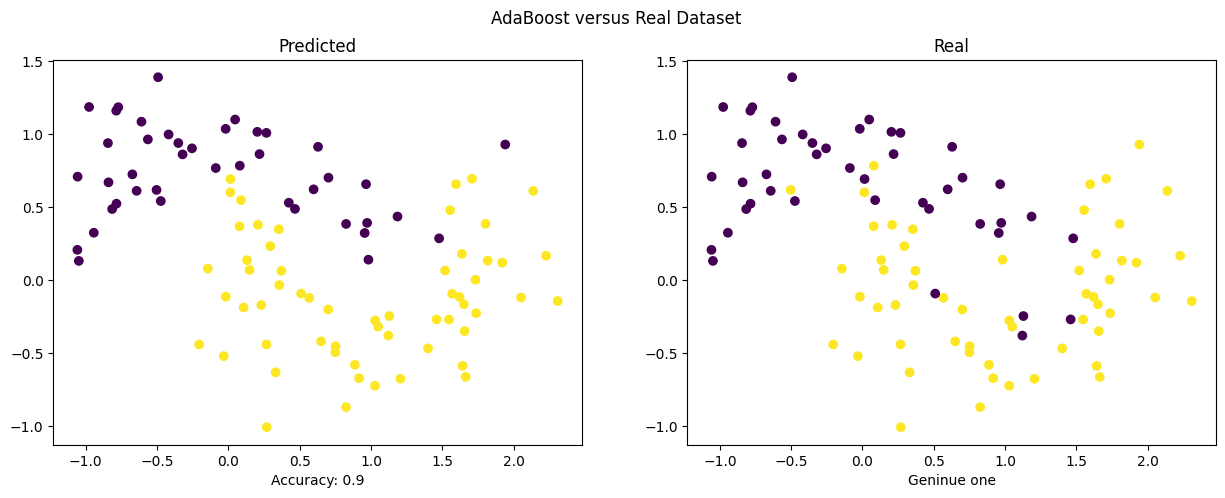

In [57]:
pltmoons(X_test, y_test, y_pred, model='AdaBoost')

In [58]:
params = {
    "n_estimators": 100,
    "criterion": "gini",          # "gini", "entropy", "log_loss"
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "min_weight_fraction_leaf": 0.0,
    "max_features": "sqrt",       # "sqrt", "log2", None, int, float
    "max_leaf_nodes": None,
    "min_impurity_decrease": 0.0,
    "bootstrap": True,
    "oob_score": False,
    "n_jobs": None,
    "random_state": None,
    "verbose": 0,
    "warm_start": False,
    "class_weight": None,         # dict, "balanced", "balanced_subsample", or None
    "ccp_alpha": 0.0,
    "max_samples": None           # only if bootstrap=True
}

rf = RandomForestClassifier(**params)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

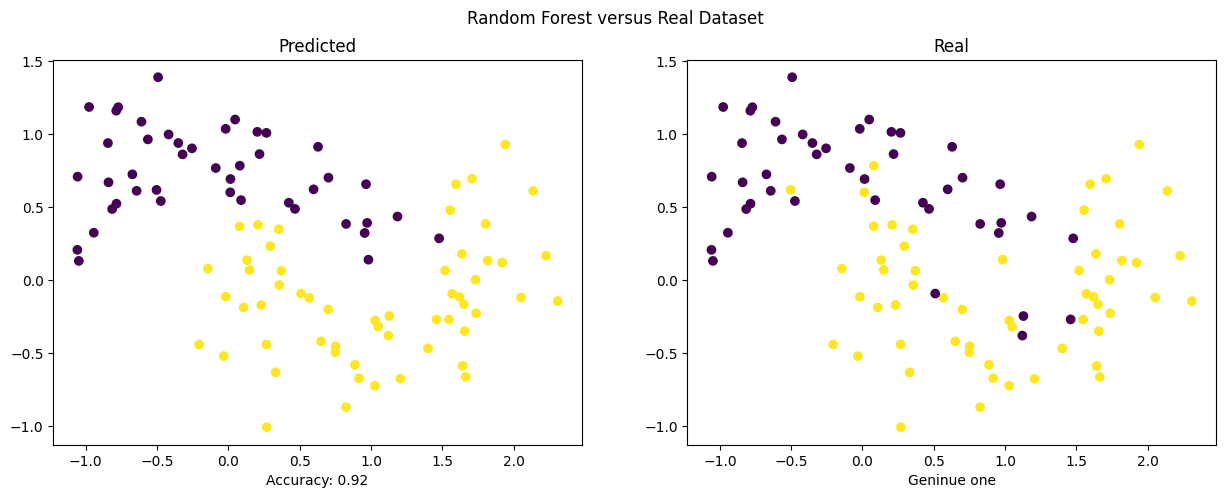

In [59]:
pltmoons(X_test, y_test, y_pred, model='Random Forest')

In [60]:
params = {
    "penalty": "l2",           # "l1", "l2", "elasticnet", None
    "C": 3.0,                  # inverse regularization strength
    "solver": "lbfgs",         # "lbfgs", "liblinear", "saga", "newton-cg", "newton-cholesky", "sag"
    "max_iter": 1000,
    "tol": 1e-4,
    "fit_intercept": True,
    "class_weight": None,      # dict, "balanced", or None
    "random_state": None,
    "warm_start": False,
    "n_jobs": None,            # works for some solvers
    "l1_ratio": None           # only for penalty="elasticnet" with solver="saga"
}

logistic = LogisticRegression(**params)
logistic.fit(X_train, y_train)

y_pred = logistic.predict(X_test)

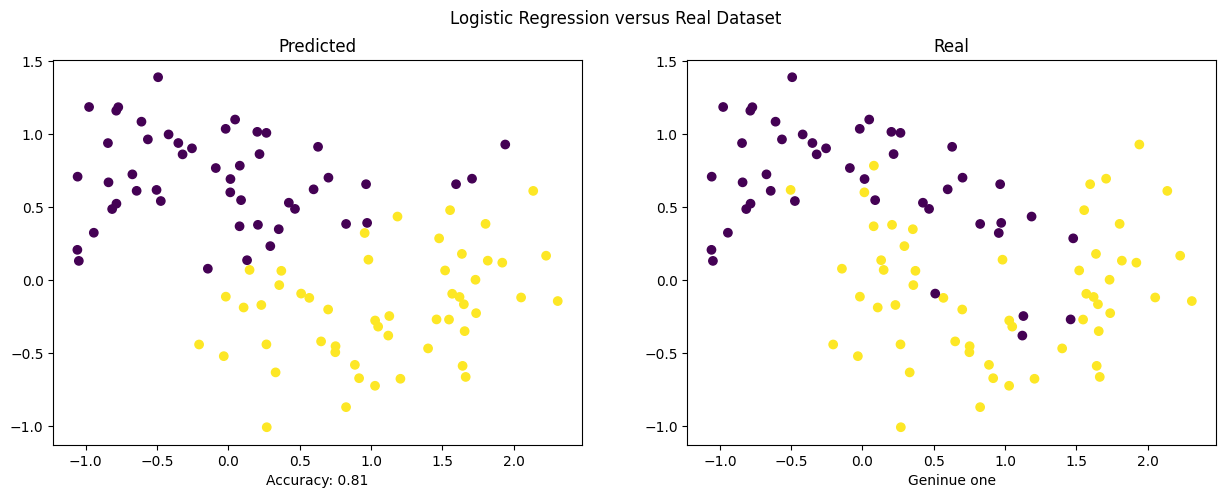

In [61]:
pltmoons(X_test, y_test, y_pred, 'Logistic Regression')

In [62]:
lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=1,   # important for small moons
    min_split_gain=0.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(X_train, y_train)

y_pred = lgbm.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


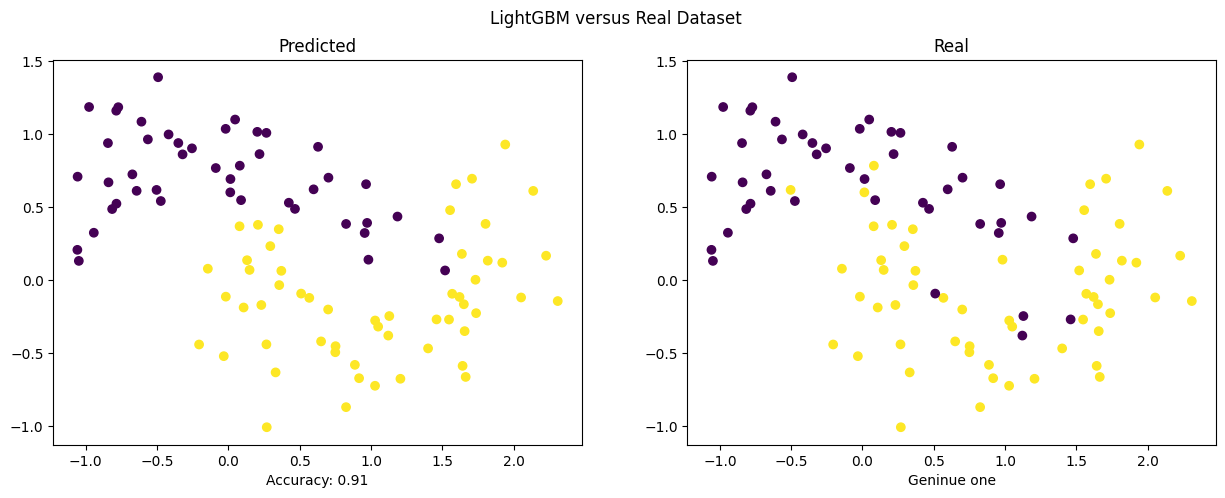

In [63]:
pltmoons(X_test, y_test, y_pred, 'LightGBM')